# NOTEBOOK A
___
* EDA - EMPLOYEES W/O TRAINING
* EDA - RETIREMENT
* ADVANCED DESCRIPTIVE ANALYSIS
* EXPANDED DATASET EXPORT

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

from mpl_toolkits.mplot3d import Axes3D
# pip install ipympl (One-time installation this if you want 3D plot rotation)
# %matplotlib widget (Optional - Always run this if you want interactive)
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

In [2]:
# DATASET LOAD & OVERVIEW
path = 'SRTEMPLOYEES2026A.csv'
df = pd.read_csv(path)
print(df.info())
print(df.isnull().sum())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 19026 entries, 0 to 19025
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          19026 non-null  str    
 1   LEVEL       19026 non-null  int64  
 2   TYPE        19026 non-null  str    
 3   DEPARTMENT  19026 non-null  str    
 4   DOB         19026 non-null  str    
 5   AGE         19026 non-null  int64  
 6   COURSE      15862 non-null  str    
 7   PILLAR      15862 non-null  float64
 8   GENERAL     19026 non-null  int64  
 9   TECHNICAL   19026 non-null  int64  
 10  DIGITAL     19026 non-null  int64  
dtypes: float64(1), int64(5), str(5)
memory usage: 1.6 MB
None
ID               0
LEVEL            0
TYPE             0
DEPARTMENT       0
DOB              0
AGE              0
COURSE        3164
PILLAR        3164
GENERAL          0
TECHNICAL        0
DIGITAL          0
dtype: int64


,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,COURSE,PILLAR,GENERAL,TECHNICAL,DIGITAL
0,SRT_1,14,Governance & Support,Governor Bureau,8/9/1971,54,โครงการพัฒนาผู้บริหารระดับสูง (Crucial Convers...,1.0,1,0,0
1,SRT_2,14,Governance & Support,Governor Bureau,11/10/1965,60,การบริหารความต่อเนื่องทางธุรกิจระดับองค์กร,1.0,1,0,0
2,SRT_3,14,Governance & Support,Governor Bureau,18/8/1970,55,NaN,NaN,0,0,0
3,SRT_4,14,Governance & Support,Governor Bureau,2/7/1967,58,NaN,NaN,0,0,0
4,SRT_5,14,Governance & Support,Governor Bureau,19/6/1969,56,NaN,NaN,0,0,0


In [3]:
# FILL MISSING VALUES FOR THOSE EMPLOYEES WITHOUT TRAINING
df['COURSE'] = df['COURSE'].fillna('N/A')
df['PILLAR'] = df['PILLAR'].fillna(0).astype(int)
df[['COURSE', 'PILLAR']].isna().sum()

COURSE    0
PILLAR    0
dtype: int64

In [4]:
df.head()

,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,COURSE,PILLAR,GENERAL,TECHNICAL,DIGITAL
0,SRT_1,14,Governance & Support,Governor Bureau,8/9/1971,54,โครงการพัฒนาผู้บริหารระดับสูง (Crucial Convers...,1,1,0,0
1,SRT_2,14,Governance & Support,Governor Bureau,11/10/1965,60,การบริหารความต่อเนื่องทางธุรกิจระดับองค์กร,1,1,0,0
2,SRT_3,14,Governance & Support,Governor Bureau,18/8/1970,55,N/A,0,0,0,0
3,SRT_4,14,Governance & Support,Governor Bureau,2/7/1967,58,N/A,0,0,0,0
4,SRT_5,14,Governance & Support,Governor Bureau,19/6/1969,56,N/A,0,0,0,0


In [4]:
# UNIQUE TYPE IN SERVICES
df['TYPE'].unique()

<StringArray>
[            'Governance & Support',                       'Operations',
   'Infrastructure & Rolling Stock', 'Strategic Business & Real Estate']
Length: 4, dtype: str

In [5]:
# CREATE A SEPARATE DATAFRAME TO DISPLAY THE TOTAL TRAINING RECEIVED
dftr = (
    df[df['COURSE'] != 'N/A'].groupby('ID', sort=False).size().reindex(df['ID'].unique(), fill_value=0).reset_index(name='TOTALTRAINING')
)
dftr.head()

,ID,TOTALTRAINING
0,SRT_1,1
1,SRT_2,1
2,SRT_3,0
3,SRT_4,0
4,SRT_5,0


___
#### EDA - EMPLOYEES WITHOUT TRAINING 
ARE THEY STRUCTURALLY DIFFERENT?

In [6]:
# GROUPING
dfid = (df.drop_duplicates('ID').merge(dftr, on='ID', how='left'))
dfid['STATUS'] = (dfid['TOTALTRAINING'] > 0).astype(int)
dfid['GROUP'] = dfid['STATUS'].map({
    0: 'NO TRAINING',
    1: 'HAS TRAINING'
})
dfid.head()

,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,COURSE,PILLAR,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING,STATUS,GROUP
0,SRT_1,14,Governance & Support,Governor Bureau,8/9/1971,54,โครงการพัฒนาผู้บริหารระดับสูง (Crucial Convers...,1,1,0,0,1,1,HAS TRAINING
1,SRT_2,14,Governance & Support,Governor Bureau,11/10/1965,60,การบริหารความต่อเนื่องทางธุรกิจระดับองค์กร,1,1,0,0,1,1,HAS TRAINING
2,SRT_3,14,Governance & Support,Governor Bureau,18/8/1970,55,N/A,0,0,0,0,0,0,NO TRAINING
3,SRT_4,14,Governance & Support,Governor Bureau,2/7/1967,58,N/A,0,0,0,0,0,0,NO TRAINING
4,SRT_5,14,Governance & Support,Governor Bureau,19/6/1969,56,N/A,0,0,0,0,0,0,NO TRAINING


In [7]:
# WORKFORCE STRUCTURE BY TYPE (WHICH TYPE IS UNDER-TRAINED?)
pd.crosstab(dfid['TYPE'], dfid['GROUP'], normalize='index').round(4)

GROUP,HAS TRAINING,NO TRAINING
TYPE,,
Governance & Support,0.8946,0.1054
Infrastructure & Rolling Stock,0.5957,0.4043
Operations,0.5902,0.4098
Strategic Business & Real Estate,0.9846,0.0154


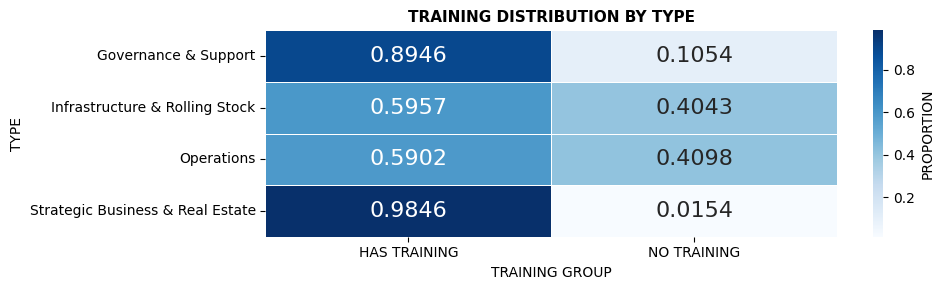

In [8]:
# HEATMAP VISUALISATION: WORKFORCE STRUCTURE BY TYPE
tg = pd.crosstab(dfid['TYPE'], dfid['GROUP'], normalize='index').round(4)
plt.figure(figsize=(10, 3))
sns.heatmap(tg, annot=True, cmap='Blues', fmt='g', linewidths=0.5, annot_kws={'size': 16}, cbar_kws={'label': 'PROPORTION'}
)
plt.title('TRAINING DISTRIBUTION BY TYPE', fontsize=11, fontweight='bold')
plt.xlabel('TRAINING GROUP')
plt.ylabel('TYPE')
plt.tight_layout()
plt.show();

In [9]:
# WORKFORCE STRUCTURE BY DEPARTMENT (WHICH DEPARTMENT IS UNDER-TRAINED?)
pd.crosstab(dfid['DEPARTMENT'], dfid['GROUP'], normalize='index').round(4)

GROUP,HAS TRAINING,NO TRAINING
DEPARTMENT,,
Board of Commissioners Coordination and Secretary Center,1.0000,0.0000
Civil Engineering Department,0.7778,0.2222
Electrified Rail Management Bureau,1.0000,0.0000
Finance and Accouting Department,0.8415,0.1585
Freight Service Department,0.6094,0.3906
Governor Bureau,0.8444,0.1556
Human Resource Department,0.8588,0.1412
Information Technology Department,0.8333,0.1667
Institute of Railway Training,1.0000,0.0000


In [10]:
# WORKFORCE STRUCTURE BY LEVEL (WHICH LEVEL IS UNDER-TRAINED?)
pd.crosstab(dfid['LEVEL'], dfid['GROUP'], normalize='index').round(4)

GROUP,HAS TRAINING,NO TRAINING
LEVEL,,
1,0.3462,0.6538
2,0.4232,0.5768
3,0.5065,0.4935
4,0.5679,0.4321
5,0.5193,0.4807
6,0.6597,0.3403
7,0.7124,0.2876
8,0.9182,0.0818
10,0.9278,0.0722


               count     mean     std   min   25%   50%   75%   max
GROUP                                                              
HAS TRAINING  5109.0  43.5937  9.6594  22.0  35.0  45.0  51.0  61.0
NO TRAINING   3164.0  47.2108  9.2787  25.0  41.0  49.0  55.0  61.0


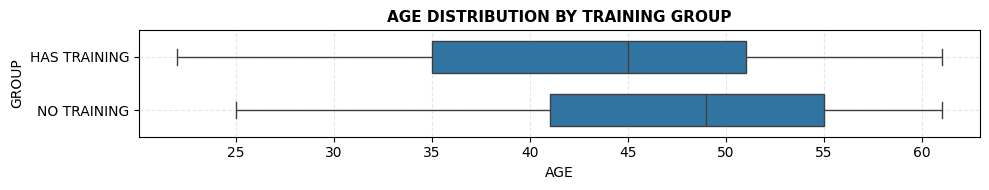

In [11]:
# DESCRIPTIVE STATISTICS + AGE DISTRIBUTION OF SLACKERS haha
print(dfid.groupby('GROUP')['AGE'].describe().round(4))

plt.figure(figsize=(10, 2))
sns.boxplot(data=dfid, x='AGE', y='GROUP', width=0.6)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlabel('AGE')
plt.ylabel('GROUP')
plt.title('AGE DISTRIBUTION BY TRAINING GROUP',fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show();

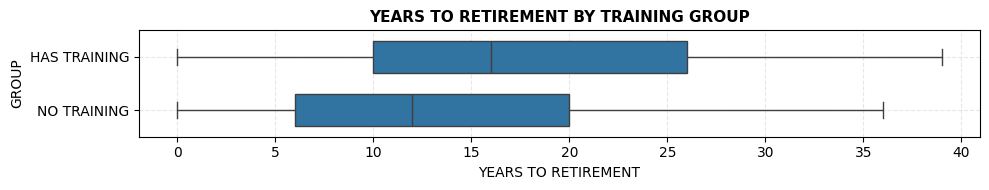

In [13]:
# AGE DISTRIBUTION OF EMPLOYEES IN YEARS TO RETIREMENT
# Untrained employees are closer to retirement. i.e. old people = no skills haha
dfid['YEARS2RETIREMENT'] = 61 - dfid['AGE']

plt.figure(figsize=(10, 2))
sns.boxplot(data=dfid, x='YEARS2RETIREMENT', y='GROUP', width=0.6)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlabel('YEARS TO RETIREMENT')
plt.ylabel('GROUP')
plt.title('YEARS TO RETIREMENT BY TRAINING GROUP', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show();

In [14]:
# WORKFORCE RISK SEGMENTATION
# High risk + no training → critical gap
# Low risk + high training → future-ready workforce
dfid['RISKGROUP'] = pd.cut(
    dfid['YEARS2RETIREMENT'],
    bins=[-1, 5, 15, 100],
    labels=['HIGH', 'MID', 'LOW']
)
pd.crosstab(dfid['RISKGROUP'], dfid['GROUP'], normalize='index').round(4)

GROUP,HAS TRAINING,NO TRAINING
RISKGROUP,,
HIGH,0.4585,0.5415
MID,0.5876,0.4124
LOW,0.7002,0.2998


In [15]:
# MULTI-VARIABLE INTERACTION - LEVEL × TYPE × TRAINING
# Are there any specific structural blind spots? Examples such as mid-level operations staff being undertrained?
pd.crosstab([dfid['TYPE'], dfid['LEVEL']], dfid['GROUP'], normalize='index').round(4)

GROUP                                   HAS TRAINING  NO TRAINING
TYPE                             LEVEL                           
Governance & Support             1            1.0000       0.0000
                                 2            0.6154       0.3846
                                 3            0.8000       0.2000
                                 5            0.7778       0.2222
                                 6            0.8925       0.1075
                                 7            0.8000       0.2000
                                 8            0.9318       0.0682
                                 10           0.9434       0.0566
                                 11           0.8750       0.1250
                                 12           0.8824       0.1176
                                 13           1.0000       0.0000
                                 14           0.3333       0.6667
Infrastructure & Rolling Stock   1            0.3404       0.6596
                                 2            0.5127       0.4873
                                 3            0.4065       0.5935
                                 4            0.5403       0.4597
                                 5            0.4354       0.5646
                                 6            0.6672       0.3328
                                 7            0.6812       0.3188
                                 8            0.8992       0.1008
                                 10           0.8876       0.1124
                                 11           0.9231       0.0769
                                 12           1.0000       0.0000
                                 13           0.7500       0.2500
Operations                       1            0.0000       1.0000
                                 2            0.3849       0.6151
                                 3            0.5392       0.4608
                                 4            0.5890       0.4110
                                 5            0.8235       0.1765
                                 6            0.5943       0.4057
                                 7            0.9149       0.0851
                                 8            0.9204       0.0796
                                 10           1.0000       0.0000
                                 12           1.0000       0.0000
                                 13           0.6667       0.3333
Strategic Business & Real Estate 2            0.5000       0.5000
                                 6            1.0000       0.0000
                                 8            1.0000       0.0000
                                 10           1.0000       0.0000
                                 11           1.0000       0.0000
                                 12           1.0000       0.0000
                                 13           1.0000       0.0000

In [25]:
# QUICK STATISTICAL TESTING: INDEPENDENT T-TEST (DIFFERENCE IN AGE)
t_stat, p_val = ttest_ind(
    dfid[dfid['STATUS'] == 0]['AGE'],
    dfid[dfid['STATUS'] == 1]['AGE'],
    equal_var=False
)
mean0 = dfid[dfid['STATUS'] == 0]['AGE'].mean()
mean1 = dfid[dfid['STATUS'] == 1]['AGE'].mean()
pd.DataFrame({
    'METRIC': ['MEAN(NO TRAINING)', 'MEAN (WITH TRAINING)', 'T-STATISTIC', 'P-VALUE'],
    'VALUE': [mean0, mean1, t_stat, p_val]
    })
# Interpretation
# On average, employees without training are 3.6 years older approximately.
# t-statistic is extremely large and p-value is effectively zero = The difference is statistically significant beyond any reasonable threshold. ie. There is no difference statistically speaking in age between trained and untrained employees.

,METRIC,VALUE
0,MEAN(NO TRAINING),4.721081e+01
1,MEAN (WITH TRAINING),4.359366e+01
2,T-STATISTIC,1.696243e+01
3,P-VALUE,2.935194e-63


In [26]:
# QUICK STATISTICAL TESTING: CHI-SQUARE TEST (CATEGORICAL ASSOCIATION TEST)
chi2_contingency(pd.crosstab(dfid['TYPE'], dfid['GROUP']))
ct = pd.crosstab(dfid['TYPE'], dfid['GROUP'])
chi2, p, dof, expected = chi2_contingency(ct)
pd.DataFrame({
    'METRIC': ['CHI-SQUARE', 'P-VALUE', 'DEGREES OF FREEDOM'],
    'VALUE': [chi2, p, dof]
})
# Interpretation
# p-value < 0.05 --> Reject the null hypothesis of independence. So there is a statistically significant association between TYPE and GROUP (training status).
# I think training allocation is not evenly distributed across functional groups but this pattern is statistically robust.

,METRIC,VALUE
0,CHI-SQUARE,2.444040e+02
1,P-VALUE,1.061954e-52
2,DEGREES OF FREEDOM,3.000000e+00


___
#### EDA - RETIREMENT

Reframing the definition:
RETIREMENTDATE (exact timestamp) - As each employee has a DOB (continuous time), retirement occurs at a deterministic event date. It is not at age = 60 or 61 directly, but at the first October 1st satisfying policy rules, therefore the primary derived variable should not be RETIREMENTDATE.
* Drop 'YEARS2RETIREMENT'
* If DOB ∈ [Jan 1 – Sep 30] → Group A
    * Retire on: Oct 1 of the same year as turn60
* If DOB ∈ [Oct 1 – Dec 31] → Group B
    * Retire on: Oct 1 of the following year after turn60

In [16]:
# NOT USING THIS. IT IS FOR THE TRAINING ANALYSIS
dfid.info()

<class 'pandas.DataFrame'>
RangeIndex: 8273 entries, 0 to 8272
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   ID                8273 non-null   str     
 1   LEVEL             8273 non-null   int64   
 2   TYPE              8273 non-null   str     
 3   DEPARTMENT        8273 non-null   str     
 4   DOB               8273 non-null   str     
 5   AGE               8273 non-null   int64   
 6   COURSE            8273 non-null   str     
 7   PILLAR            8273 non-null   int64   
 8   GENERAL           8273 non-null   int64   
 9   TECHNICAL         8273 non-null   int64   
 10  DIGITAL           8273 non-null   int64   
 11  TOTALTRAINING     8273 non-null   int64   
 12  STATUS            8273 non-null   int64   
 13  GROUP             8273 non-null   str     
 14  YEARS2RETIREMENT  8273 non-null   int64   
 15  RISKGROUP         8273 non-null   category
dtypes: category(1), int64(9), str(6)
me

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19026 entries, 0 to 19025
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   ID          19026 non-null  str  
 1   LEVEL       19026 non-null  int64
 2   TYPE        19026 non-null  str  
 3   DEPARTMENT  19026 non-null  str  
 4   DOB         19026 non-null  str  
 5   AGE         19026 non-null  int64
 6   COURSE      19026 non-null  str  
 7   PILLAR      19026 non-null  int64
 8   GENERAL     19026 non-null  int64
 9   TECHNICAL   19026 non-null  int64
 10  DIGITAL     19026 non-null  int64
dtypes: int64(6), str(5)
memory usage: 1.6 MB


In [17]:
# REDO DATASET: COLLAPSE ON ID + EXCLUDE TWO COLUMNS + ADD ONE NEW COLUMN
dfr = (
    df.groupby('ID', sort=False, as_index=False)
      .agg({
          'LEVEL': 'first',
          'TYPE': 'first',
          'DEPARTMENT': 'first',
          'DOB': 'first',
          'AGE': 'first',
          'GENERAL': 'sum',
          'TECHNICAL': 'sum',
          'DIGITAL': 'sum'
      })
)
dfr['TOTALTRAINING'] = dfr[['GENERAL', 'TECHNICAL', 'DIGITAL']].sum(axis=1)
dfr.head()

,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING
0,SRT_1,14,Governance & Support,Governor Bureau,8/9/1971,54,1,0,0,1
1,SRT_2,14,Governance & Support,Governor Bureau,11/10/1965,60,1,0,0,1
2,SRT_3,14,Governance & Support,Governor Bureau,18/8/1970,55,0,0,0,0
3,SRT_4,14,Governance & Support,Governor Bureau,2/7/1967,58,0,0,0,0
4,SRT_5,14,Governance & Support,Governor Bureau,19/6/1969,56,0,0,0,0


In [30]:
dfr.info()

<class 'pandas.DataFrame'>
RangeIndex: 8273 entries, 0 to 8272
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ID             8273 non-null   str  
 1   LEVEL          8273 non-null   int64
 2   TYPE           8273 non-null   str  
 3   DEPARTMENT     8273 non-null   str  
 4   DOB            8273 non-null   str  
 5   AGE            8273 non-null   int64
 6   GENERAL        8273 non-null   int64
 7   TECHNICAL      8273 non-null   int64
 8   DIGITAL        8273 non-null   int64
 9   TOTALTRAINING  8273 non-null   int64
dtypes: int64(6), str(4)
memory usage: 646.5 KB


In [18]:
# RETIREMENTYEAR MULTIPSTEPS: DATETIME DOB + EXTRACTION OF COMPONENTS + RETIREMENT DATE PRINT + UPDATE AGE
dfr['DOB'] = pd.to_datetime(dfr['DOB'], format='%d/%m/%Y', errors='coerce')
dfr['TURN60'] = dfr['DOB'] + pd.DateOffset(years=60)
dobm = dfr['DOB'].dt.month
turn60y = dfr['TURN60'].dt.year
dfr['RETIREMENTYEAR'] = turn60y + (dobm >= 10).astype('Int64')
dfr['RETIREMENTDATE'] = pd.to_datetime(dict(year=dfr['RETIREMENTYEAR'], month=10, day=1))

currentdate = pd.Timestamp('2026-01-01')
dfr['AGE'] = ((currentdate - dfr['DOB']).dt.days / 365.25).round(2)
dfr.head()

,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING,TURN60,RETIREMENTYEAR,RETIREMENTDATE
0,SRT_1,14,Governance & Support,Governor Bureau,1971-09-08,54.32,1,0,0,1,2031-09-08,2031,2031-10-01
1,SRT_2,14,Governance & Support,Governor Bureau,1965-10-11,60.22,1,0,0,1,2025-10-11,2026,2026-10-01
2,SRT_3,14,Governance & Support,Governor Bureau,1970-08-18,55.37,0,0,0,0,2030-08-18,2030,2030-10-01
3,SRT_4,14,Governance & Support,Governor Bureau,1967-07-02,58.50,0,0,0,0,2027-07-02,2027,2027-10-01
4,SRT_5,14,Governance & Support,Governor Bureau,1969-06-19,56.54,0,0,0,0,2029-06-19,2029,2029-10-01


In [32]:
dfr.info()

<class 'pandas.DataFrame'>
RangeIndex: 8273 entries, 0 to 8272
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID              8273 non-null   str           
 1   LEVEL           8273 non-null   int64         
 2   TYPE            8273 non-null   str           
 3   DEPARTMENT      8273 non-null   str           
 4   DOB             8273 non-null   datetime64[us]
 5   AGE             8273 non-null   float64       
 6   GENERAL         8273 non-null   int64         
 7   TECHNICAL       8273 non-null   int64         
 8   DIGITAL         8273 non-null   int64         
 9   TOTALTRAINING   8273 non-null   int64         
 10  TURN60          8273 non-null   datetime64[us]
 11  RETIREMENTYEAR  8273 non-null   Int64         
 12  RETIREMENTDATE  8273 non-null   datetime64[us]
dtypes: Int64(1), datetime64[us](3), float64(1), int64(5), str(3)
memory usage: 848.4 KB


In [19]:
# QUICK CHECK ON INVALID DOB PROCESSING
faileddob = dfr['DOB'].isna().sum()
print(f'INVALID DOB ROWS: {faileddob}')

INVALID DOB ROWS: 0


In [20]:
# FIND AVERAGE AGE & THE MEDIAN RETIRE YEAR
print(f'THE AVERAGE AGE OF CURRENT EMPLOYEES: {dfr['AGE'].mean():.2f}')
print(f'THE MEDIAN RETIREMENT YEAR FOR CURRENT EMPLOYEES: {dfr['RETIREMENTYEAR'].median()}')

THE AVERAGE AGE OF CURRENT EMPLOYEES: 45.42
THE MEDIAN RETIREMENT YEAR FOR CURRENT EMPLOYEES: 2039.0


In [21]:
# FIND THE NUMBER OF RETIREES FOR EACH YEAR FROM 2027 TO 2060 (POLICY COMPLIANT)
years = pd.RangeIndex(2027, 2061)
rt = (dfr[dfr['RETIREMENTYEAR'].between(2027, 2060)].groupby(['RETIREMENTYEAR', 'TYPE']).size().unstack(fill_value=0).reindex(years, fill_value=0))
rcounts = rt.astype('int32')
rcounts

TYPE,Governance & Support,Infrastructure & Rolling Stock,Operations,Strategic Business & Real Estate
2027,14,142,146,1
2028,16,150,127,0
2029,19,155,147,3
2030,15,113,133,1
2031,31,138,134,2
2032,23,102,139,1
2033,15,137,112,3
2034,26,138,123,4
2035,38,162,151,6
2036,24,193,124,4


In [22]:
# DISTRIBUTION ANALYSIS - GROUPED BY TYPE ON THEIR AGES
dfr.groupby('TYPE')['AGE'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
TYPE,,,,,,,,
Governance & Support,579.0,45.36,9.82,23.88,36.99,47.43,53.34,60.38
Infrastructure & Rolling Stock,4408.0,45.13,9.66,21.96,37.21,46.70,52.56,61.19
Operations,3221.0,45.87,9.63,24.10,37.35,47.62,54.11,60.24
Strategic Business & Real Estate,65.0,43.10,10.18,25.66,33.79,43.96,51.47,60.17


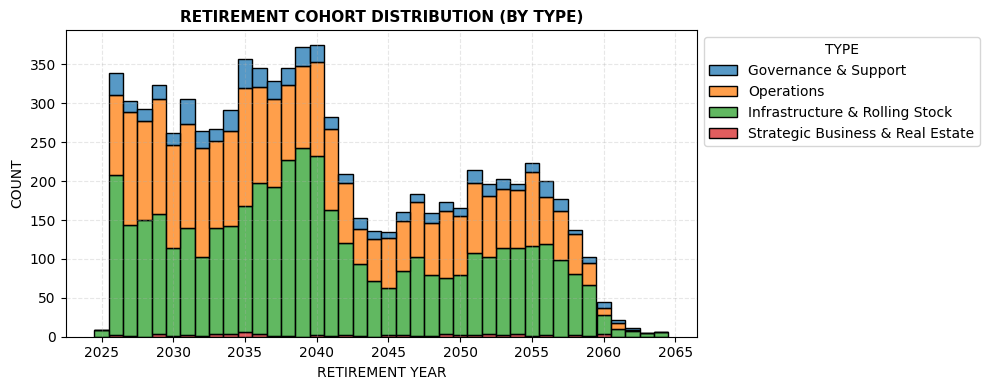

In [ ]:
# FISCAL COHORT FRAMEWORK: RETIREMENT COHORT DISTRIBUTION (BY TYPE) - HISTOGRAM
# Note: this system has shifted from age-driven retirement to date-triggered retirement (Oct 1 cohorts).
# Interpretation: Right skew (positive) → longer tail to older ages / longer remaining years & Left skew (negative) → concentration near retirement
dfp = dfr.dropna(subset=['RETIREMENTYEAR', 'TYPE'])
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=dfp, x='RETIREMENTYEAR', hue='TYPE', multiple='stack', discrete=True, ax=ax)
ax.set_title('RETIREMENT COHORT DISTRIBUTION (BY TYPE)', fontsize=11, fontweight='bold')
ax.set_xlabel('RETIREMENT YEAR')
ax.set_ylabel('COUNT')
ax.grid(True, linestyle='--', alpha=0.3)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='TYPE')
plt.tight_layout()
plt.show();

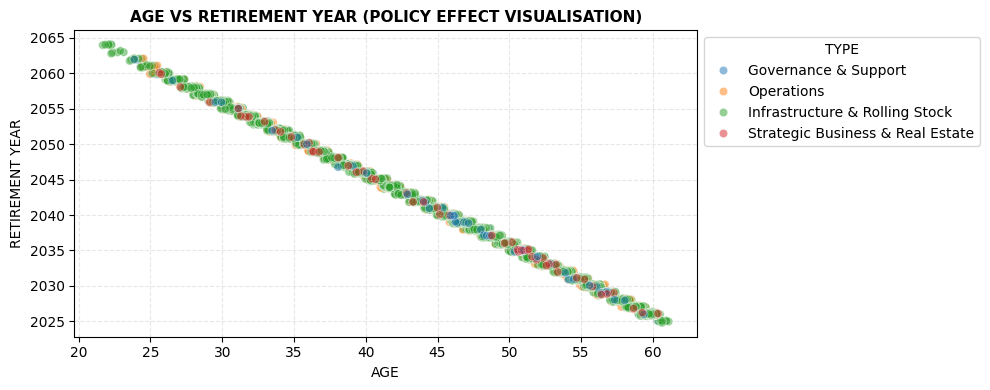

In [ ]:
# FISCAL COHORT FRAMEWORK: AGE VS RETIREMENT (BY TYPE) - SCATTERPLOT
dfp = dfr.dropna(subset=['RETIREMENTYEAR', 'TYPE', 'AGE']).copy()
dfp['AGEJITTER'] = dfp['AGE'] + np.random.normal(0, 0.15, size=len(dfp))
dfp['RYEARJITTER'] = dfp['RETIREMENTYEAR'] + np.random.normal(0, 0.1, size=len(dfp))

fig, ax = plt.subplots(figsize=(10, 4))
sns.scatterplot(data=dfp, x='AGEJITTER', y='RYEARJITTER', hue='TYPE', alpha=0.5, ax=ax)
ax.set_title('AGE VS RETIREMENT YEAR (POLICY EFFECT VISUALISATION)', fontsize=11, fontweight='bold')
ax.set_xlabel('AGE')
ax.set_ylabel('RETIREMENT YEAR')
ax.grid(True, linestyle='--', alpha=0.3)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='TYPE')
plt.tight_layout()
plt.show();

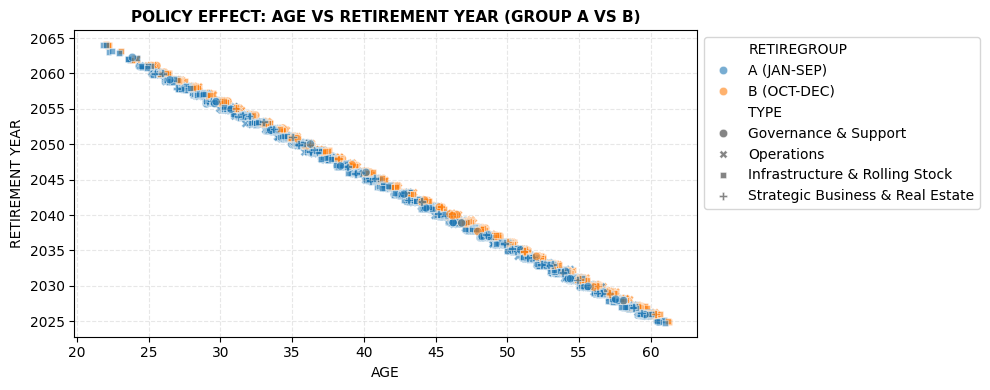

In [ ]:
# FISCAL COHORT FRAMEWORK: AGE VS RETIREMENT (BY TYPE & GROUP) - SCATTERPLOT
dfr['RETIREGROUP'] = np.where(dfr['DOB'].dt.month <= 9, 'A (JAN-SEP)', 'B (OCT-DEC)')
dfp = dfr.dropna(subset=['AGE', 'RETIREMENTYEAR', 'RETIREGROUP']).copy()
dfp['AGEJITTER'] = dfp['AGE'] + np.random.normal(0, 0.15, size=len(dfp))
dfp['RYEARJITTER'] = dfp['RETIREMENTYEAR'] + np.random.normal(0, 0.1, size=len(dfp))
fig, ax = plt.subplots(figsize=(10, 4))
sns.scatterplot(data=dfp, x='AGEJITTER', y='RYEARJITTER', hue='RETIREGROUP', style='TYPE', alpha=0.6, ax=ax)

ax.set_title('POLICY EFFECT: AGE VS RETIREMENT YEAR (GROUP A VS B)', fontsize=11, fontweight='bold')
ax.set_xlabel('AGE')
ax.set_ylabel('RETIREMENT YEAR')
ax.grid(True, linestyle='--', alpha=0.3)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('F1.png', dpi=600, bbox_inches='tight')
plt.show();

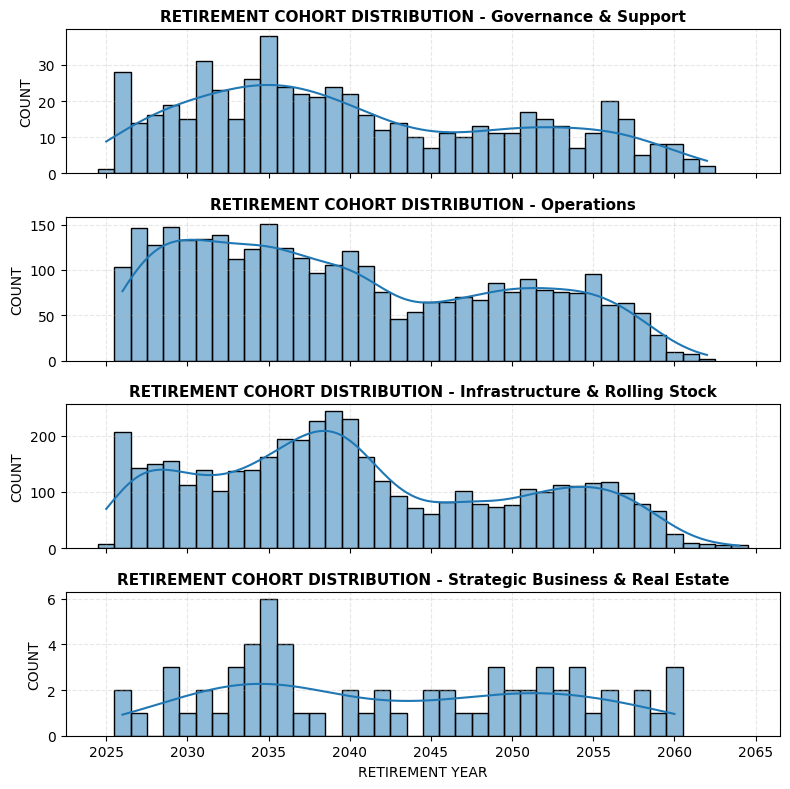

In [26]:
# FISCAL COHORT FRAMEWORK: RETIREMENT COHORT DISTRIBUTION - HISTOGRAM
ty = dfr['TYPE'].dropna().unique()
fig, axes = plt.subplots(len(ty), 1, figsize=(8, 2 * len(ty)), sharex=True)
if len(ty) == 1:
    axes = [axes]

dfp = dfr.dropna(subset=['RETIREMENTYEAR', 'TYPE'])
for ax, t in zip(axes, ty):
    subset = dfp[dfp['TYPE'] == t]
    sns.histplot(data=subset, x='RETIREMENTYEAR', discrete=True, bins=20, kde=True, ax=ax)
    ax.set_title(f'RETIREMENT COHORT DISTRIBUTION - {t}', fontsize=11, fontweight='bold')
    ax.set_xlabel('RETIREMENT YEAR')
    ax.set_ylabel('COUNT')
    ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show();

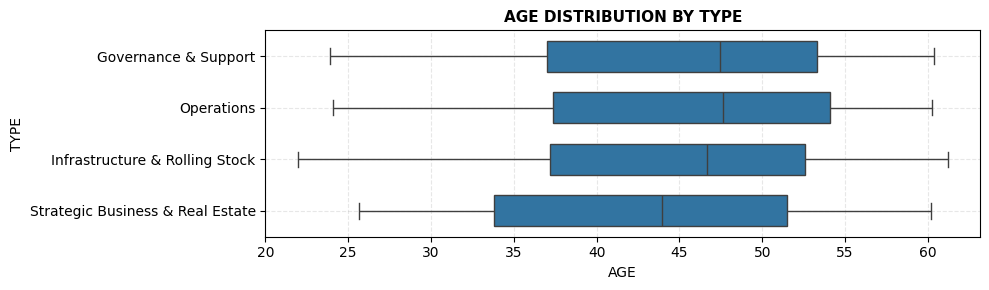

In [27]:
# AGE DISTRIBUTION - HORIZONTAL BOXPLOT
# Interpretation: Boxplot asymmetry → median not centered in box & Outliers → potential data issues or special cases
plt.figure(figsize=(10, 3))
sns.boxplot(data=dfr, x='AGE', y='TYPE', width=0.6)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlabel('AGE')
plt.ylabel('TYPE')
plt.title('AGE DISTRIBUTION BY TYPE', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show();

In [28]:
# NUMERICAL SKEWNESS - AGE DISTRIBUTION
dfr.groupby('TYPE')['AGE'].skew().round(4)

TYPE
Governance & Support               -0.4258
Infrastructure & Rolling Stock     -0.3379
Operations                         -0.3707
Strategic Business & Real Estate   -0.1379
Name: AGE, dtype: float64

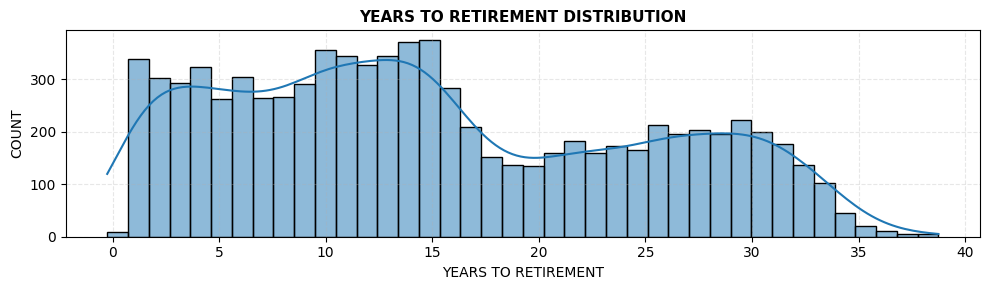

In [29]:
# YEARS TO RETIREMENT DISTRIBUTION (GENERAL; NOT BY TYPE) - HISTOGRAM
currentdate = pd.Timestamp('2026-01-01')
dfr['YEARS2RETIREMENT'] = ((dfr['RETIREMENTDATE'] - currentdate).dt.days / 365.25).round(2)
plt.figure(figsize=(10, 3))
sns.histplot(dfr['YEARS2RETIREMENT'], bins=40, kde=True)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlabel('YEARS TO RETIREMENT')
plt.ylabel('COUNT')
plt.title('YEARS TO RETIREMENT DISTRIBUTION', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show();

In [30]:
dfr.info()

<class 'pandas.DataFrame'>
RangeIndex: 8273 entries, 0 to 8272
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID                8273 non-null   str           
 1   LEVEL             8273 non-null   int64         
 2   TYPE              8273 non-null   str           
 3   DEPARTMENT        8273 non-null   str           
 4   DOB               8273 non-null   datetime64[us]
 5   AGE               8273 non-null   float64       
 6   GENERAL           8273 non-null   int64         
 7   TECHNICAL         8273 non-null   int64         
 8   DIGITAL           8273 non-null   int64         
 9   TOTALTRAINING     8273 non-null   int64         
 10  TURN60            8273 non-null   datetime64[us]
 11  RETIREMENTYEAR    8273 non-null   Int64         
 12  RETIREMENTDATE    8273 non-null   datetime64[us]
 13  RETIREGROUP       8273 non-null   str           
 14  YEARS2RETIREMENT  8273 non-null   f

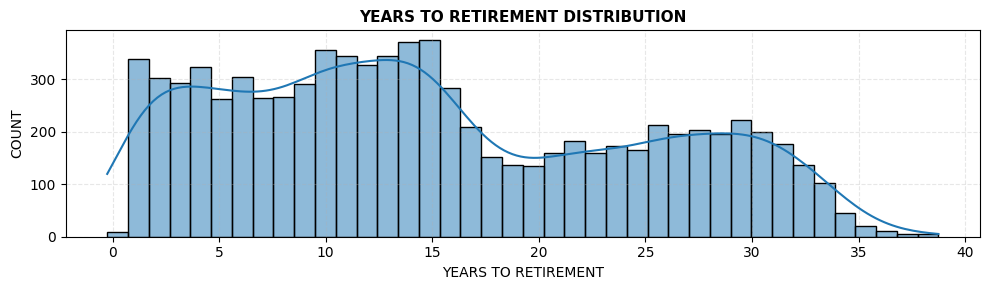

In [ ]:
# YEARS TO RETIREMENT DISTRIBUTION - HISTOGRAM
plt.figure(figsize=(10, 3))
sns.histplot(dfr['YEARS2RETIREMENT'], bins=40, kde=True)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlabel('YEARS TO RETIREMENT')
plt.ylabel('COUNT')
plt.title('YEARS TO RETIREMENT DISTRIBUTION', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show();

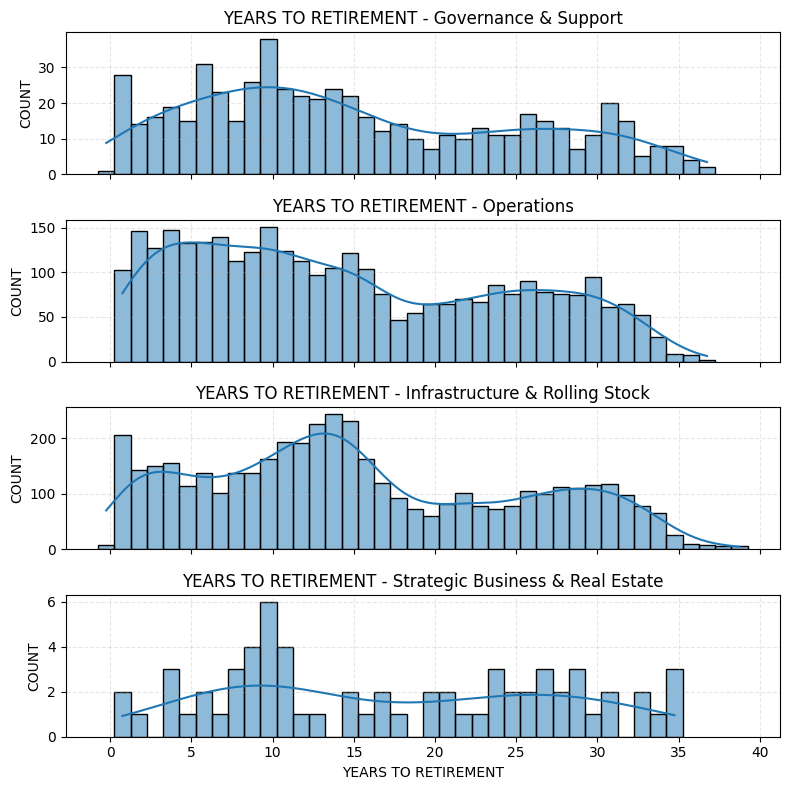

In [ ]:
# YEARS TO RETIREMENT DISTRIBUTION - HISTOGRAM
# Optional since we already have FISCAL COHORT FRAMEWORK: RETIREMENT COHORT DISTRIBUTION - HISTOGRAM - The distributions are the same.
ty = dfr['TYPE'].unique()
fig, axes = plt.subplots(len(ty), 1, figsize=(8, 2 * len(ty)), sharex=True)
for ax, t in zip(axes, ty):
    sns.histplot(data=dfr[dfr['TYPE'] == t], x='YEARS2RETIREMENT', discrete=True, bins=20, kde=True, ax=ax)
    ax.set_title(f'YEARS TO RETIREMENT - {t}')
    ax.set_xlabel('YEARS TO RETIREMENT')
    ax.set_ylabel('COUNT')
    ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show();

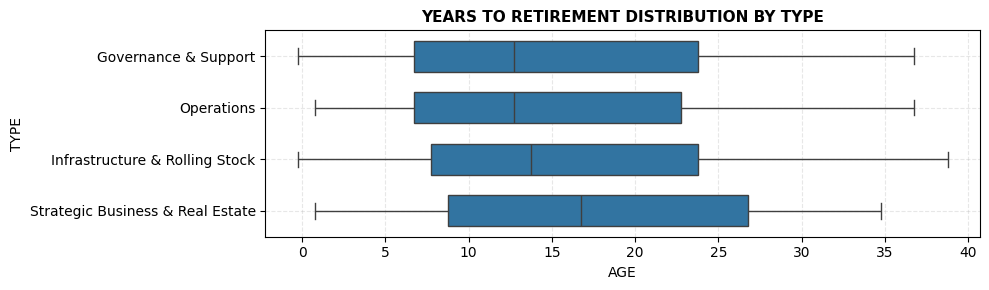

In [33]:
# YEARS TO RETIREMENT DISTRIBUTION - HORIZONTAL BOXPLOT
plt.figure(figsize=(10, 3))
sns.boxplot(data=dfr, x='YEARS2RETIREMENT', y='TYPE', width=0.6)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlabel('AGE')
plt.ylabel('TYPE')
plt.title('YEARS TO RETIREMENT DISTRIBUTION BY TYPE',fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show();

In [34]:
# NUMERICAL SKEWNESS - YEARS TO RETIREMENT DISTRIBUTION
dfr.groupby('TYPE')['YEARS2RETIREMENT'].skew().round(4)

TYPE
Governance & Support                0.4247
Infrastructure & Rolling Stock      0.3389
Operations                          0.3737
Strategic Business & Real Estate    0.1395
Name: YEARS2RETIREMENT, dtype: float64

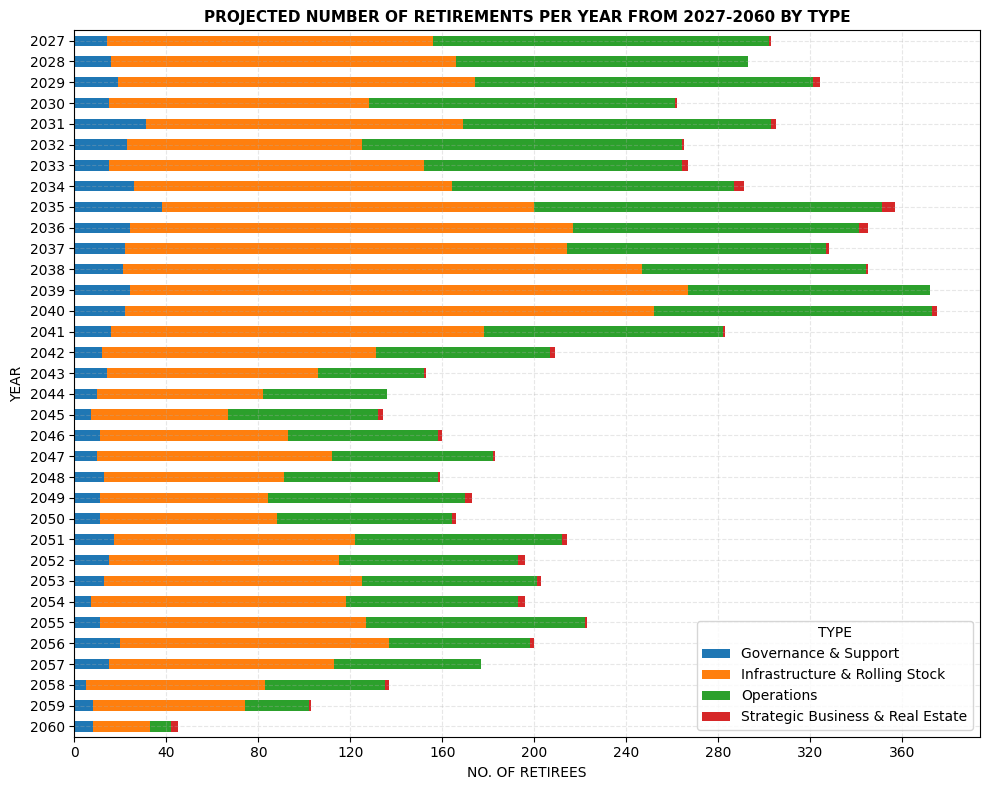

In [35]:
# PLOT THE COMBINED NUMBER OF RETIREES BY TYPE FOR EACH YEAR FROM 2027 TO 2060 (POLICY COMPLIANT)
# BASED ON RETIREMENT YEAR
rt = rt.sort_index(ascending=False)
rt.plot(kind='barh', stacked=True, figsize=(10, 8))
plt.grid(True, linestyle='--', alpha=0.3)
plt.ylabel('YEAR')
plt.xlabel('NO. OF RETIREES')
plt.title('PROJECTED NUMBER OF RETIREMENTS PER YEAR FROM 2027-2060 BY TYPE', fontsize=11, fontweight='bold')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('F2.png', dpi=600, bbox_inches='tight')
plt.show();

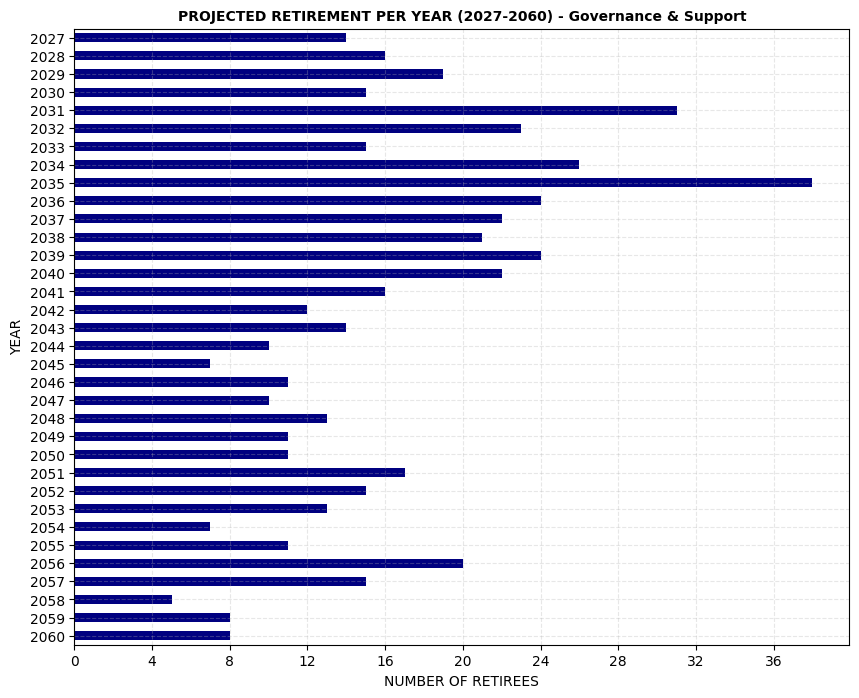

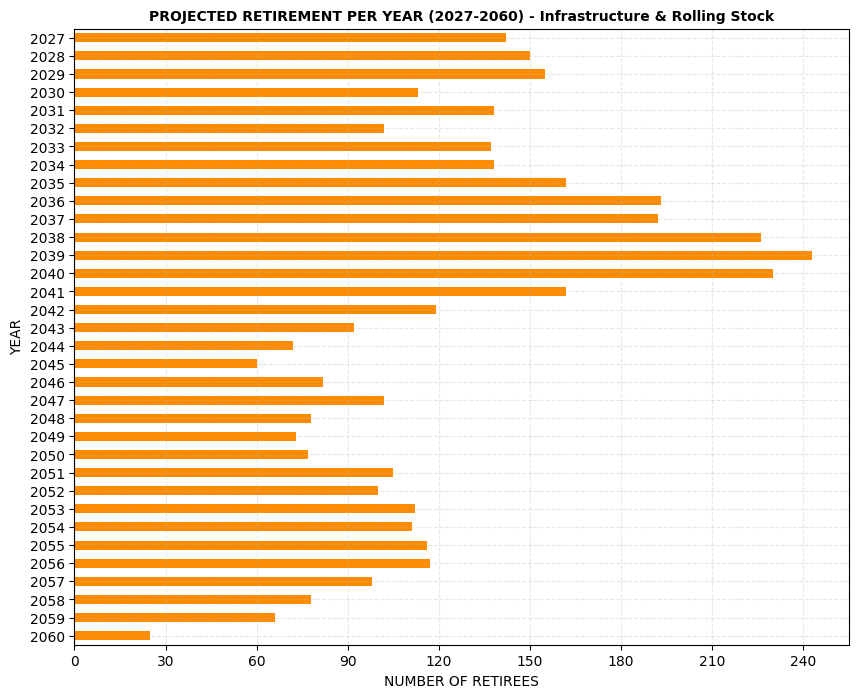

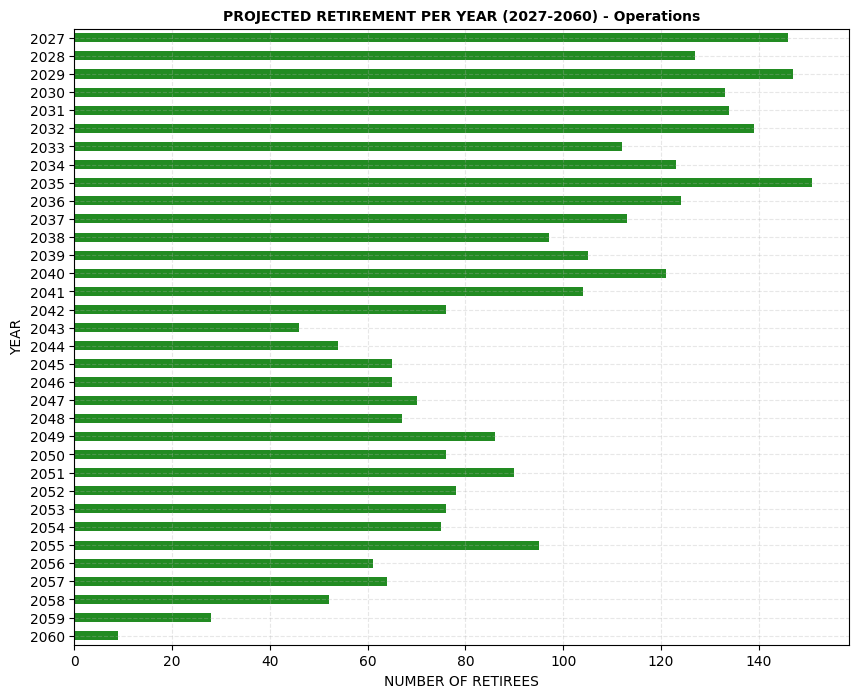

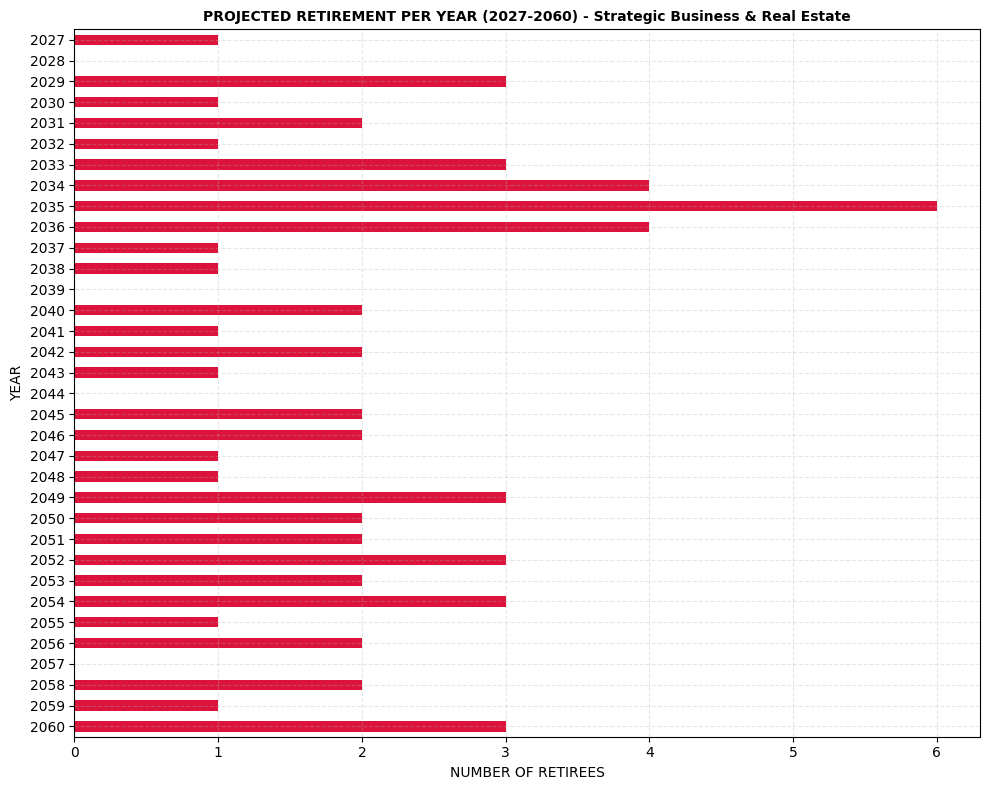

In [36]:
# PLOT THE NUMBER OF RETIREES FOR EACH YEAR FROM 2027 TO 2060 (SEPARATED BY TYPE) VERSION A
rt1 = rt.sort_index(ascending=False)
c = ['navy', 'darkorange', 'forestgreen', 'crimson']
for i, col in enumerate(rt1.columns):
    plt.figure(figsize=(10, 8))
    rt1[col].plot(kind='barh', color=c[i])    
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.ylabel('YEAR')
    plt.xlabel('NUMBER OF RETIREES')
    plt.title(f'PROJECTED RETIREMENT PER YEAR (2027-2060) - {col}', fontsize=10, fontweight='bold')
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show();

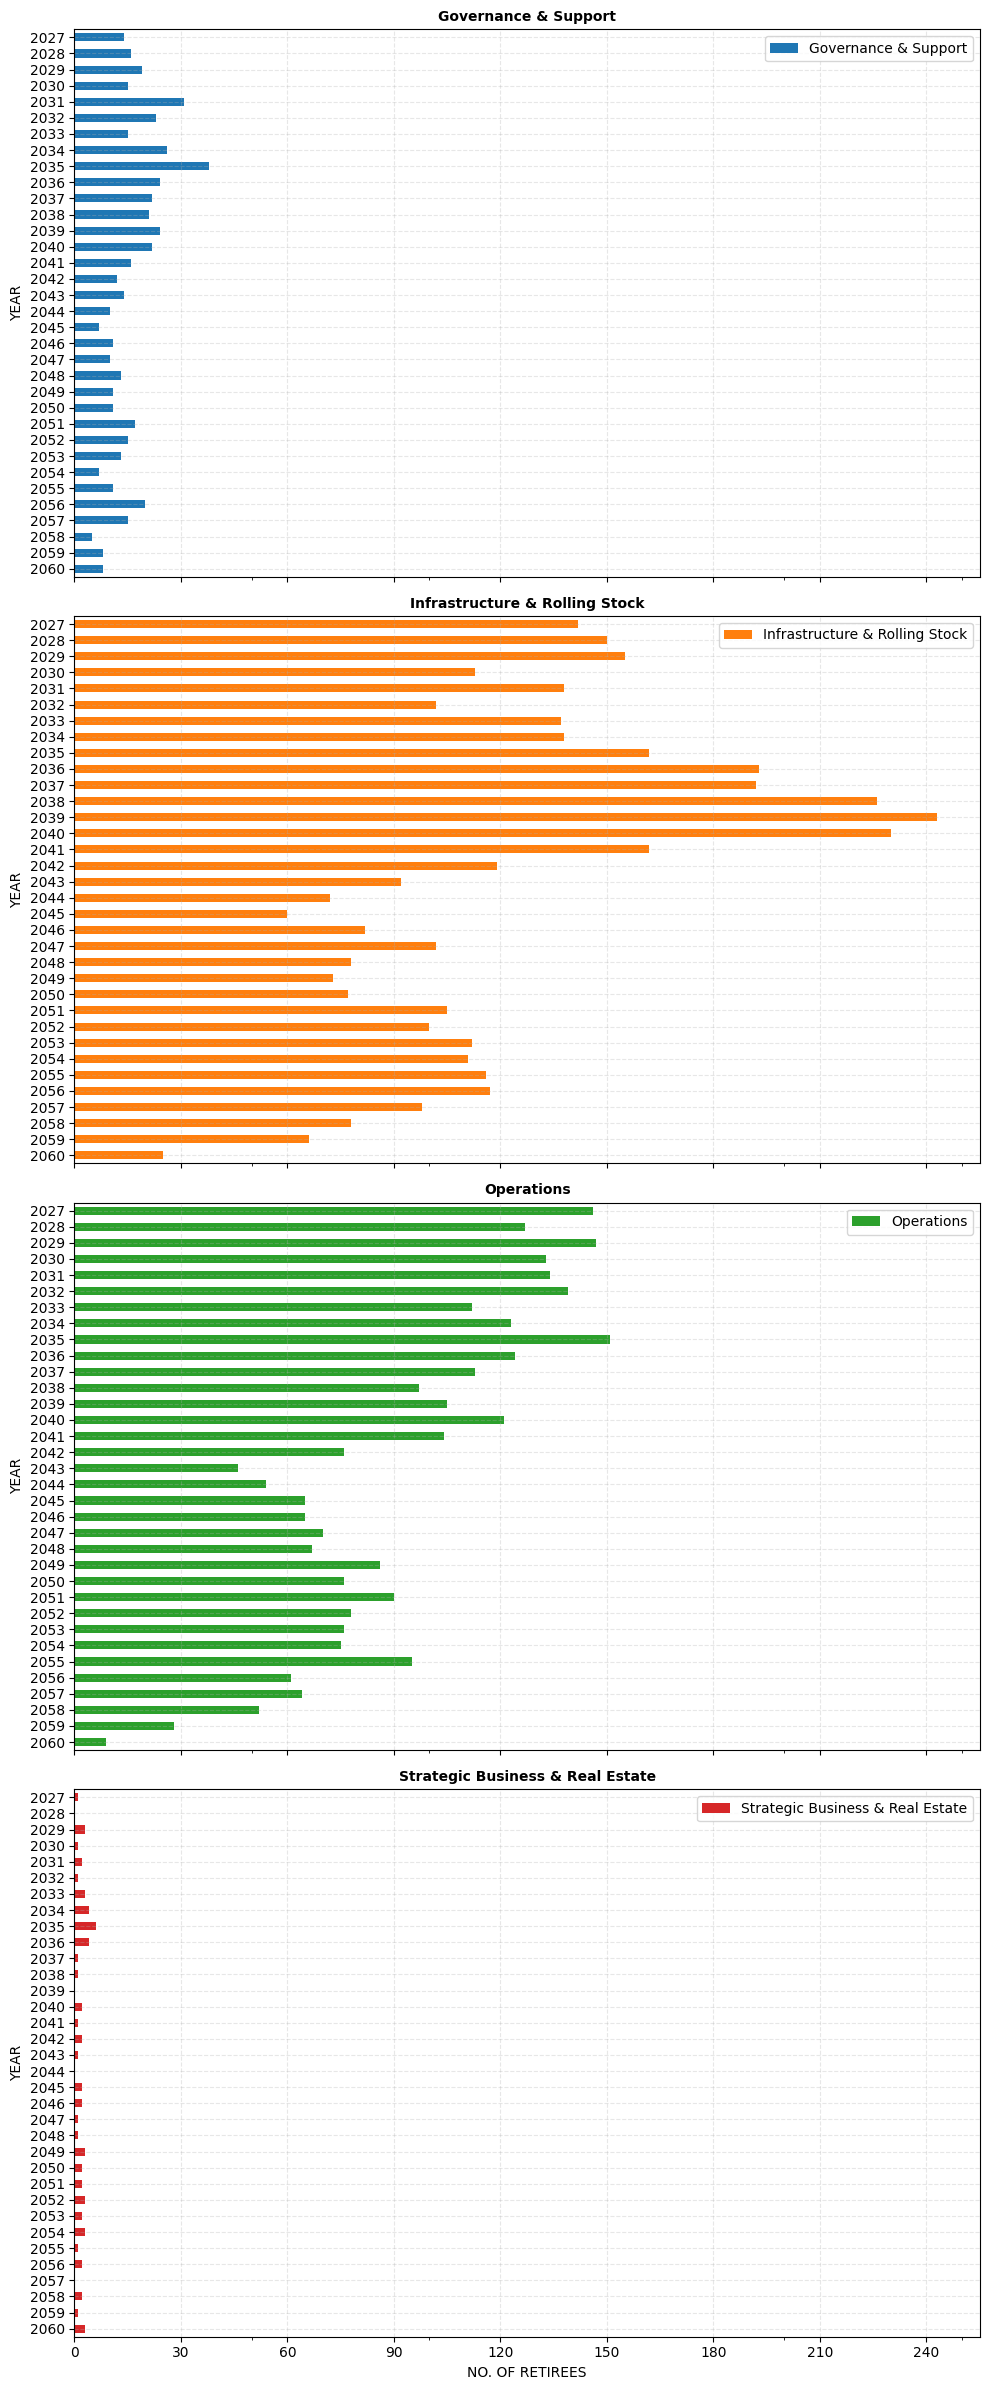

In [55]:
# PLOT THE NUMBER OF RETIREES FOR EACH YEAR FROM 2027 TO 2060 (SEPARATED BY TYPE) VERSION B
rt2 = rt.sort_index(ascending=False)
axes = rt2.plot(kind='barh', subplots=True, layout=(4, 1), figsize=(10, 24), sharex=True)
axes = axes.flatten()
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_title(ax.get_title(), fontsize=10, fontweight='bold')
    ax.set_ylabel('YEAR')
    ax.set_xlabel('NO. OF RETIREES')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show();

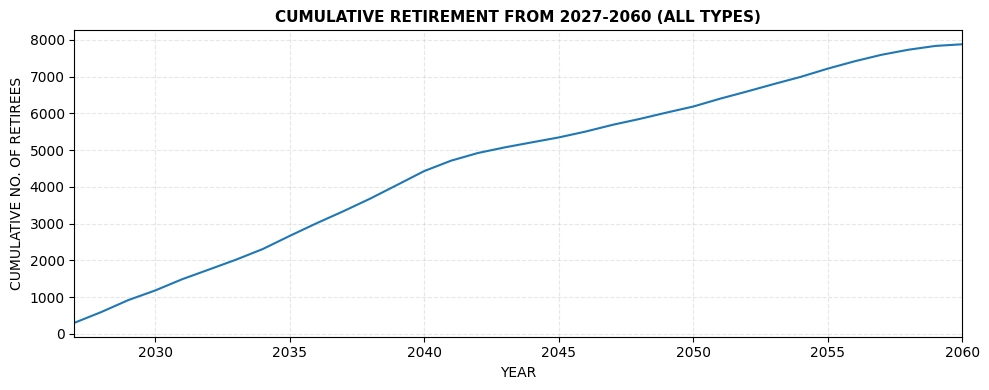

In [37]:
# PLOT THE COMBINED CUMULATIVE NUMBER OF RETIREES FOR EACH YEAR FROM 2027 TO 2060 (ALL TYPES)
cr = rcounts.cumsum()
crt = cr.sum(axis=1)
plt.figure(figsize=(10, 4))
plt.plot(crt.index, crt.values)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlabel('YEAR')
plt.ylabel('CUMULATIVE NO. OF RETIREES')
plt.title('CUMULATIVE RETIREMENT FROM 2027-2060 (ALL TYPES)', fontsize=11, fontweight='bold')
plt.xlim(crt.index[0], crt.index[-1])
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show();

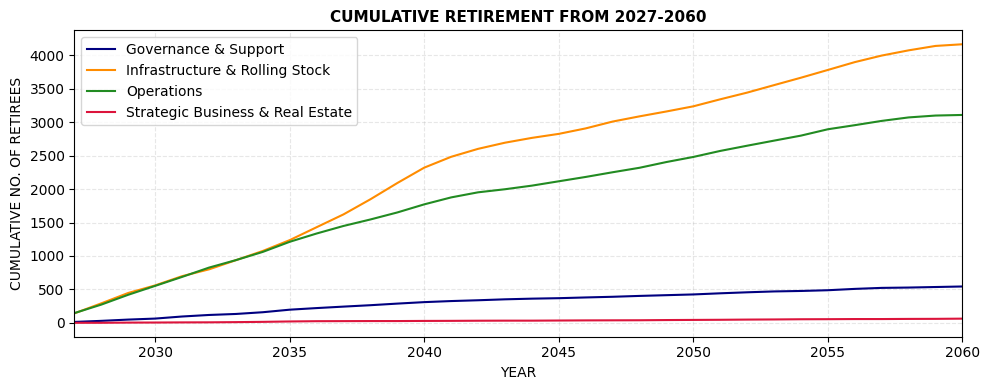

In [38]:
# PLOT THE CUMULATIVE NUMBER OF RETIREES FOR EACH YEAR FROM 2027 TO 2060 (SEPARATED BY TYPE) VERSION A
cr = rcounts.cumsum()
plt.figure(figsize=(10, 4))
c = ['navy', 'darkorange', 'forestgreen', 'crimson']
for i, col in enumerate(cr.columns):
    plt.plot(cr.index, cr[col], label=col, color=c[i])
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlabel('YEAR')
plt.ylabel('CUMULATIVE NO. OF RETIREES')
plt.title('CUMULATIVE RETIREMENT FROM 2027-2060', fontsize=11, fontweight='bold')
plt.xlim(cr.index[0], cr.index[-1])
plt.legend()
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show();

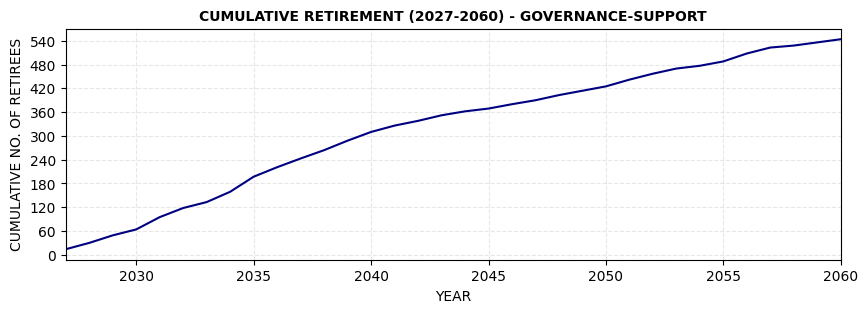

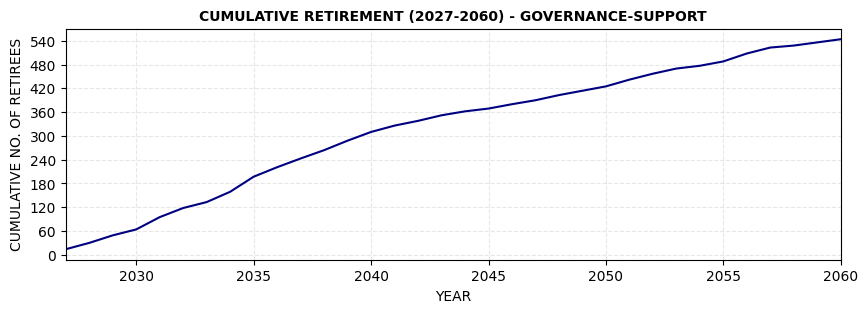

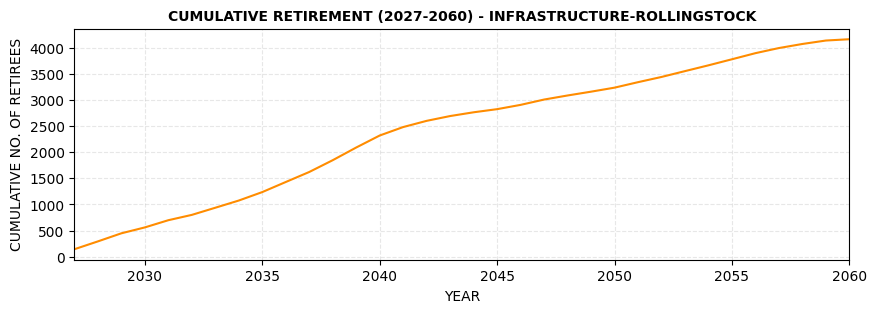

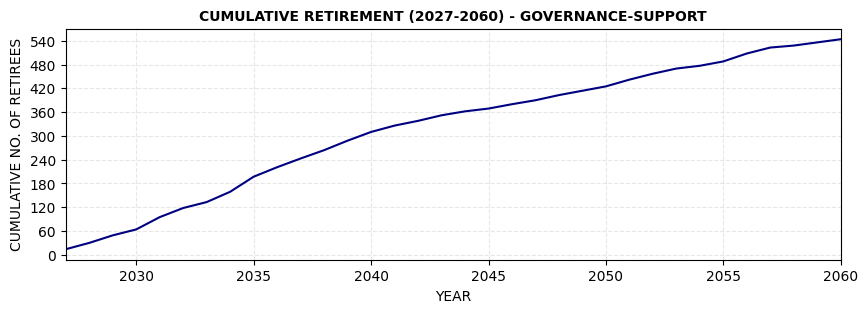

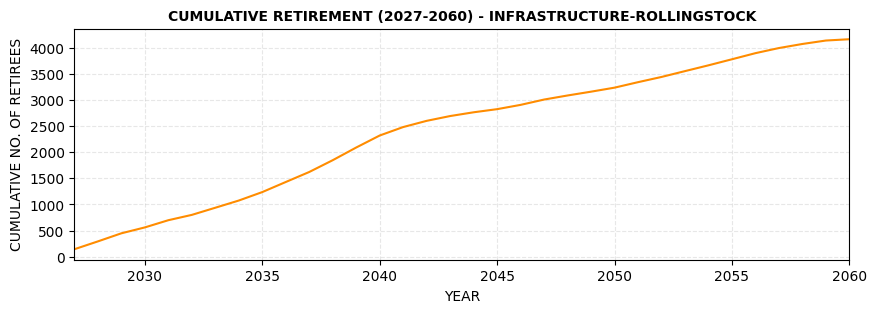

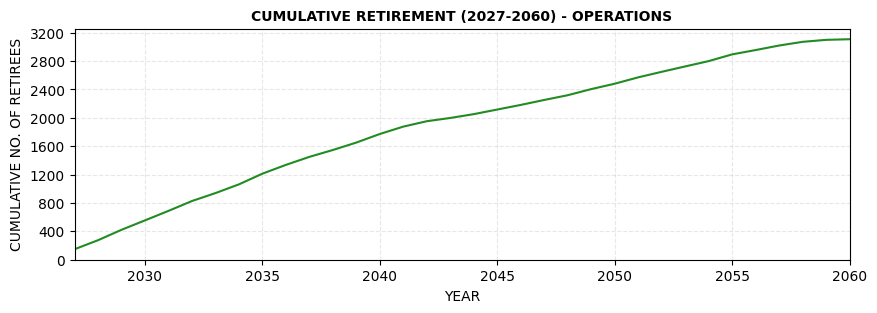

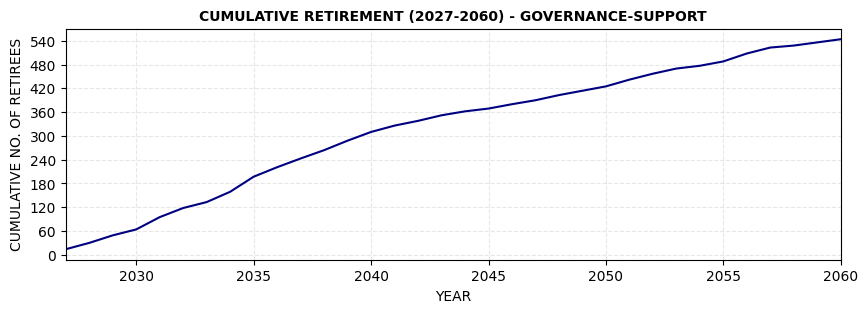

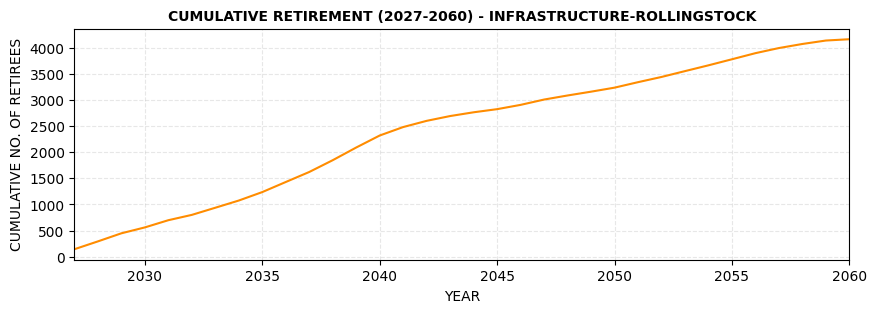

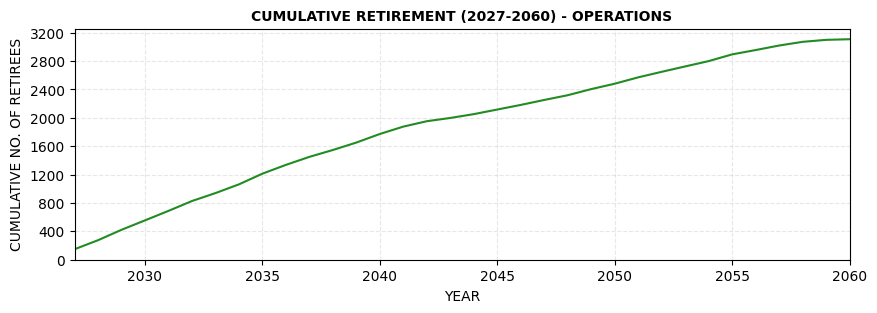

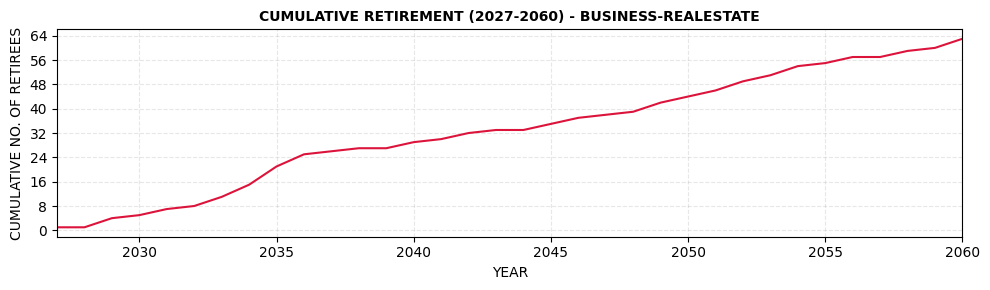

In [63]:
# PLOT THE CUMULATIVE NUMBER OF RETIREES FOR EACH YEAR FROM 2027 TO 2060 (SEPARATED BY TYPE) VERSION B
rt1 = rcounts.rename(columns={
    'Governance & Support': 'GOVERNANCE-SUPPORT',
    'Infrastructure & Rolling Stock': 'INFRASTRUCTURE-ROLLINGSTOCK',
    'Operations': 'OPERATIONS',
    'Strategic Business & Real Estate': 'BUSINESS-REALESTATE'
    })
cr1 = rt1.cumsum()

c = ['navy', 'darkorange', 'forestgreen', 'crimson']
for i, col in enumerate(cr1.columns):
    plt.figure(figsize=(10, 3))    
    plt.plot(cr1.index, cr1[col], color=c[i])    
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.xlabel('YEAR')
    plt.ylabel('CUMULATIVE NO. OF RETIREES')
    plt.title(f'CUMULATIVE RETIREMENT (2027-2060) - {col}', fontsize=10, fontweight='bold')
    plt.xlim(cr1.index[0], cr1.index[-1])
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show();

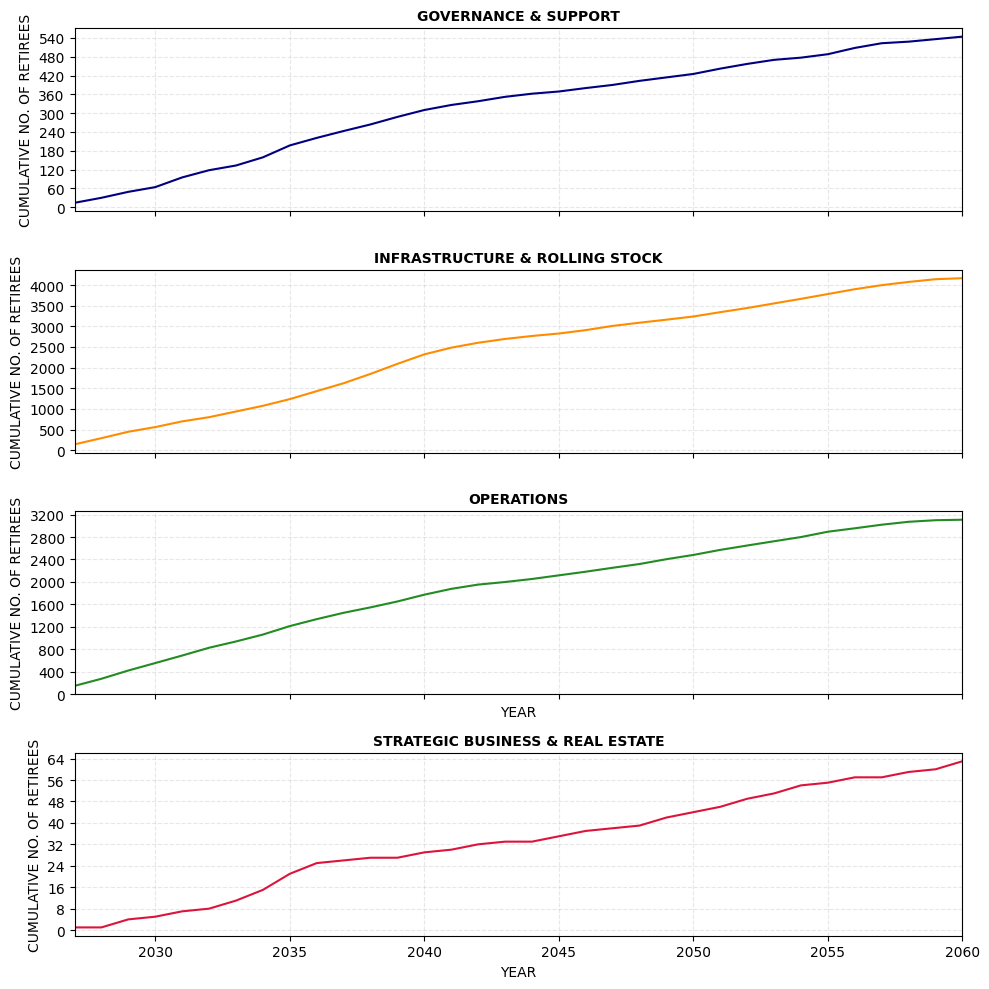

In [64]:
# PLOT THE CUMULATIVE NUMBER OF RETIREES FOR EACH YEAR FROM 2027 TO 2060 (SEPARATED BY TYPE) VERSION C
rt1 = rcounts.rename(columns={
    'Governance & Support': 'GOVERNANCE-SUPPORT',
    'Infrastructure & Rolling Stock': 'INFRASTRUCTURE-ROLLINGSTOCK',
    'Operations': 'OPERATIONS',
    'Strategic Business & Real Estate': 'BUSINESS-REALESTATE'
    })
cr1 = rt1.cumsum()
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

axes[0].plot(cr1.index, cr1['GOVERNANCE-SUPPORT'], color='navy')
axes[0].set_title('GOVERNANCE & SUPPORT', fontsize=10, fontweight='bold')
axes[0].set_ylabel('CUMULATIVE NO. OF RETIREES')
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))

axes[1].plot(cr1.index, cr1['INFRASTRUCTURE-ROLLINGSTOCK'], color='darkorange')
axes[1].set_title('INFRASTRUCTURE & ROLLING STOCK', fontsize=10, fontweight='bold')
axes[1].set_ylabel('CUMULATIVE NO. OF RETIREES')
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))

axes[2].plot(cr1.index, cr1['OPERATIONS'], color='forestgreen')
axes[2].set_title('OPERATIONS', fontsize=10, fontweight='bold')
axes[2].set_ylabel('CUMULATIVE NO. OF RETIREES')
axes[2].set_xlabel('YEAR')
axes[2].grid(True, linestyle='--', alpha=0.3)
axes[2].yaxis.set_major_locator(MaxNLocator(integer=True))

axes[3].plot(cr1.index, cr1['BUSINESS-REALESTATE'], color='crimson')
axes[3].set_title('STRATEGIC BUSINESS & REAL ESTATE', fontsize=10, fontweight='bold')
axes[3].set_ylabel('CUMULATIVE NO. OF RETIREES')
axes[3].set_xlabel('YEAR')
axes[3].grid(True, linestyle='--', alpha=0.3)
axes[3].yaxis.set_major_locator(MaxNLocator(integer=True))

for ax in axes:
    ax.set_xlim(cr1.index[0], cr1.index[-1])
plt.tight_layout()
plt.show();

___
#### INTERACTIVE LOOKUP FUNCTION

In [48]:
# INFORMATION RETRIEVAL - NUMBER OF RETIREES BY YEAR
# Note: Based on the existing rounts dataframe
def get(rcounts):
    while True:
        ui = input("ENTER A YEAR (2027-2060) OR 'q' TO QUIT: ")
        if ui.lower() == 'q':
            print('\nEND')
            break
        
        try:
            year = int(ui)
            if year < 2027 or year > 2060:
                print('OUT OF RANGE. ENTER BETWEEN 2027-2060')
                continue
                
            row = rcounts.loc[year]
            print(f'\n----RETIREMENT SUMMARY FOR {year}----')
            print(f'TOTAL NUMBER OF RETIREES: {row.sum()}')           
            for c in rcounts.columns:
                print(f'{c}: {row[c]}')
        except:
            print('\nINVALID INPUT')

get(rcounts)


----RETIREMENT SUMMARY FOR 2028----
TOTAL NUMBER OF RETIREES: 293
Governance & Support: 16
Infrastructure & Rolling Stock: 150
Operations: 127
Strategic Business & Real Estate: 0

END


In [49]:
# INFORMATION RETRIEVAL - COURSE TRAINING INFORMATION BASED ON ID
def huh(df):
    uid = input('ENTER ID: ').strip()
    result = df[df['ID'] == uid]
    if result.empty:
        print('ID NOT FOUND')
        return
    
    rec = result.shape[0]
    print(f'ID: {uid}')
    print(f'TOTAL NUMBER OF COURSE COMPLETED: {rec}\n')
    
    for _, row in result.iterrows():
        print(f'COURSE NAME: {row['COURSE']}')
        print(f'   PILLAR TYPE: {row['PILLAR']}')
        print('-' * 60)
    
huh(df)

ID: SRT_21
TOTAL NUMBER OF COURSE COMPLETED: 4

COURSE NAME: โครงการฝึกซ้อมดับเพลิง/อพยพหนีไฟ
   PILLAR TYPE: 2
------------------------------------------------------------
COURSE NAME: ความรู้ทั่วไปเกี่ยวกับความปลอดภัยในการทำงานสำหรับพนักงาน/พนักงานใหม่
   PILLAR TYPE: 2
------------------------------------------------------------
COURSE NAME: สัมมนาธรรมาภิบาล
   PILLAR TYPE: 1
------------------------------------------------------------
COURSE NAME: โครงการฝึกซ้อมดับเพลิง/อพยพหนีไฟ
   PILLAR TYPE: 2
------------------------------------------------------------


___
#### ADVANCED ANALYSIS

In [65]:
dfr.head()

,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING,TURN60,RETIREMENTYEAR,RETIREMENTDATE,RETIREGROUP,YEARS2RETIREMENT
0,SRT_1,14,Governance & Support,Governor Bureau,1971-09-08,54.32,1,0,0,1,2031-09-08,2031,2031-10-01,A (JAN-SEP),5.75
1,SRT_2,14,Governance & Support,Governor Bureau,1965-10-11,60.22,1,0,0,1,2025-10-11,2026,2026-10-01,B (OCT-DEC),0.75
2,SRT_3,14,Governance & Support,Governor Bureau,1970-08-18,55.37,0,0,0,0,2030-08-18,2030,2030-10-01,A (JAN-SEP),4.75
3,SRT_4,14,Governance & Support,Governor Bureau,1967-07-02,58.50,0,0,0,0,2027-07-02,2027,2027-10-01,A (JAN-SEP),1.75
4,SRT_5,14,Governance & Support,Governor Bureau,1969-06-19,56.54,0,0,0,0,2029-06-19,2029,2029-10-01,A (JAN-SEP),3.75


In [66]:
# WORKFORCE RISK PROFILLING - RISK CONCENTRATION
# Retirement risk bands - Segment employees by proximity to retirement:
# * 0–5 years (critical)
# * 6–10 years (medium-term)
# * 10 years (long-term)
# Insight: Identifies immediate attrition pressure by TYPE
def riskband(y):
    if y <= 5:
        return '0-5'
    elif y <= 10:
        return '6-10'
    else:
        return '10+'

dfr['RETIREMENTRISK'] = dfr['YEARS2RETIREMENT'].apply(riskband)

dfr['RETIREMENTRISK'] = pd.Categorical(dfr['RETIREMENTRISK'], categories=['0-5', '6-10', '10+'], ordered=True)
rs = (dfr.groupby(['TYPE', 'RETIREMENTRISK'], observed=False).size().unstack(fill_value=0))
rs

RETIREMENTRISK,0-5,6-10,10+
TYPE,,,
Governance & Support,93,133,353
Infrastructure & Rolling Stock,774,677,2957
Operations,656,659,1906
Strategic Business & Real Estate,7,16,42


In [ ]:
# PEAK RETIREMENT LOAD ANALYSIS - QUANTIFYING STRESS POINTS
pyears = rcounts.idxmax()
pvalues = rcounts.max()
total = rcounts.sum(axis=1)
print(f'PEAK YEAR (ALL TYPE): {total.idxmax()}')
print(f'HIGHEST COUNT (ALL TYPE): {total.max()}')
pd.DataFrame({'PEAK-YEAR': pyears, 'PEAK-COUNT': pvalues})

PEAK YEAR (ALL TYPE): 2040
HIGHEST COUNT (ALL TYPE): 375


PEAK YEAR (ALL TYPE): 2040
HIGHEST COUNT (ALL TYPE): 375


,PEAK-YEAR,PEAK-COUNT
TYPE,,
Governance & Support,2035,38
Infrastructure & Rolling Stock,2039,243
Operations,2035,151
Strategic Business & Real Estate,2035,6


In [ ]:
# REPLACEMENT DEMAND FORECASTING (USE THIS ONLY FOR REFERENCE)
demand = rcounts.rolling(window=3, min_periods=1).mean().round(0)
demand

TYPE,Governance & Support,Infrastructure & Rolling Stock,Operations,Strategic Business & Real Estate
2027,14.0,142.0,146.0,1.0
2028,15.0,146.0,136.0,0.0
2029,16.0,149.0,140.0,1.0
2030,17.0,139.0,136.0,1.0
2031,22.0,135.0,138.0,2.0
2032,23.0,118.0,135.0,1.0
2033,23.0,126.0,128.0,2.0
2034,21.0,126.0,125.0,3.0
2035,26.0,146.0,129.0,4.0
2036,29.0,164.0,133.0,5.0


In [69]:
# RISK OF SKILL LOSS (BASED ON AGE)
# Insight: Higher values → greater institutional knowledge loss risk
rsl = dfr[dfr['YEARS2RETIREMENT'] <= 5].groupby('TYPE')['AGE'].mean().round(2)
rsl

TYPE
Governance & Support                57.97
Infrastructure & Rolling Stock      58.01
Operations                          57.67
Strategic Business & Real Estate    57.81
Name: AGE, dtype: float64

In [70]:
# DEPENDANCY RATIO (STRATEGIC WORKFORCE HEALTH)
# Insight: High ratio → structural imbalance (Understanding the sustainability of workforce structure)
working = dfr[dfr['YEARS2RETIREMENT'] > 5].shape[0]
retiring = dfr[dfr['YEARS2RETIREMENT'] <= 5].shape[0]
dr = retiring / working
round(dr, 4)

0.2269

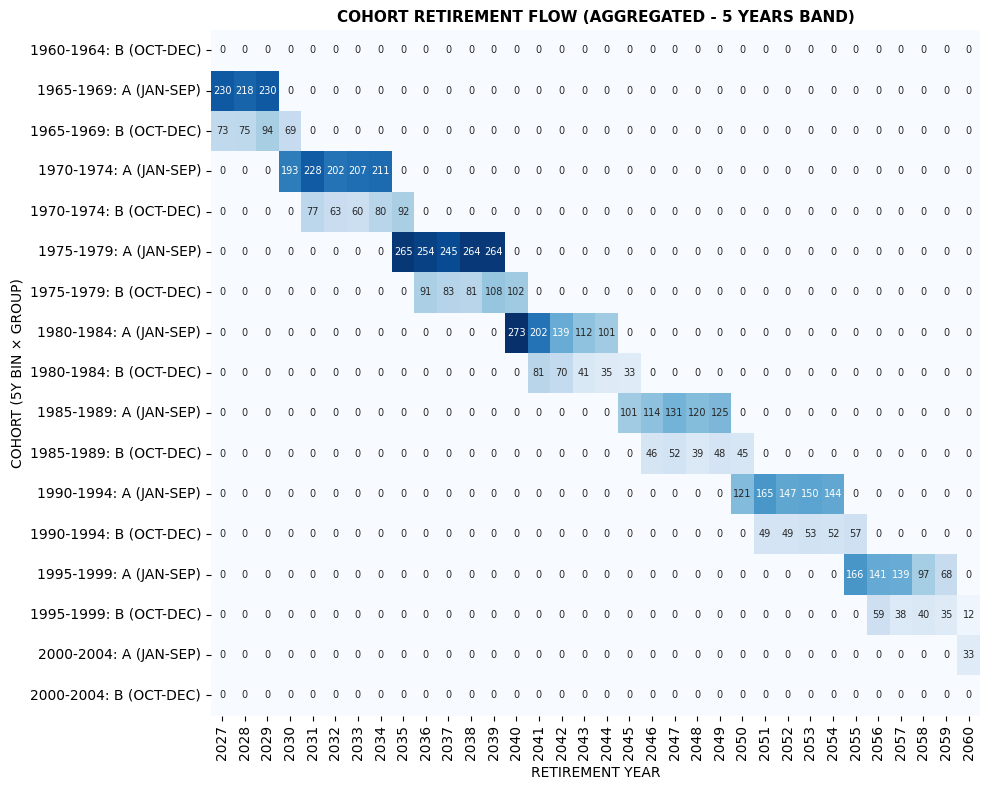

In [71]:
# 5 YEARS AGGREGATED BAND - COHORT FLOW ANALYSIS - TO TRACK HOW COHORTS EXIST OVER TIME (SAME AS THE NUMBER OF YEARLY RETIREES BUT PRESENTED IN HEATMAP)
# Insight: Reveals retirement waves in 5 years band + Reveals structural policy effects
dfr['YOB'] = dfr['DOB'].dt.year
dfr['YOBBIN'] = (dfr['YOB'] // 5) * 5
dfr['COHORTBIN'] = (dfr['YOBBIN'].astype(str) + '-' + (dfr['YOBBIN'] + 4).astype(str) + ': ' + dfr['RETIREGROUP'])
coh = (dfr.groupby(['COHORTBIN', 'RETIREMENTYEAR']).size().unstack(fill_value=0).loc[:, 2027:2060].sort_index())

plt.figure(figsize=(10, 8))
sns.heatmap(coh, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 7})
plt.xlabel('RETIREMENT YEAR')
plt.ylabel('COHORT (5Y BIN × GROUP)')
plt.title('COHORT RETIREMENT FLOW (AGGREGATED - 5 YEARS BAND)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show();

In [ ]:
# SCENARIO SIMULATION - WHAT IF THE OFFICIAL RETIREMENT AGE IS SHIFTED FROM 60 TO 65? OOPS!
# Insight: Quantifies policy impact on workforce continuity
dfr['TURN65'] = dfr['DOB'] + pd.DateOffset(years=65)
turn65y = dfr['TURN65'].dt.year
dfr['RETIREMENTYEAR65'] = turn65y + (dobm >= 10).astype(int)

years = pd.RangeIndex(2027, 2061)
r65 = (dfr.dropna(subset=['RETIREMENTYEAR65', 'TYPE']).query('RETIREMENTYEAR65 >= 2027 and RETIREMENTYEAR65 <= 2060').groupby(['RETIREMENTYEAR65', 'TYPE'], observed=False).size().unstack(fill_value=0).reindex(years, fill_value=0))
r65

TYPE,Governance & Support,Infrastructure & Rolling Stock,Operations,Strategic Business & Real Estate
2027,0,0,0,0
2028,0,0,0,0
2029,0,0,0,0
2030,1,8,0,0
2031,28,206,103,2
2032,14,142,146,1
2033,16,150,127,0
2034,19,155,147,3
2035,15,113,133,1
2036,31,138,134,2


In [59]:
# REMOVE COLUMNS PRIOR TO EXPORTING
dfr = dfr.drop(columns=['RETIREMENTRISK', 'YOB', 'YOBBIN', 'COHORTBIN', 'TURN65', 'RETIREMENTYEAR65'])

In [60]:
# LAST CHECK ON THE NOW MODIFIED DATASET
dfr.head()

,ID,LEVEL,TYPE,DEPARTMENT,DOB,AGE,GENERAL,TECHNICAL,DIGITAL,TOTALTRAINING,TURN60,RETIREMENTYEAR,RETIREMENTDATE,RETIREGROUP,YEARS2RETIREMENT
0,SRT_1,14,Governance & Support,Governor Bureau,1971-09-08,54.32,1,0,0,1,2031-09-08,2031,2031-10-01,A (JAN-SEP),5.75
1,SRT_2,14,Governance & Support,Governor Bureau,1965-10-11,60.22,1,0,0,1,2025-10-11,2026,2026-10-01,B (OCT-DEC),0.75
2,SRT_3,14,Governance & Support,Governor Bureau,1970-08-18,55.37,0,0,0,0,2030-08-18,2030,2030-10-01,A (JAN-SEP),4.75
3,SRT_4,14,Governance & Support,Governor Bureau,1967-07-02,58.50,0,0,0,0,2027-07-02,2027,2027-10-01,A (JAN-SEP),1.75
4,SRT_5,14,Governance & Support,Governor Bureau,1969-06-19,56.54,0,0,0,0,2029-06-19,2029,2029-10-01,A (JAN-SEP),3.75


___
**PROCESSED DATASET - EXPORTING**

In [ ]:
# CHECK COLUMNS
dfr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8273 entries, 0 to 8272
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID                8273 non-null   object        
 1   LEVEL             8273 non-null   int64         
 2   TYPE              8273 non-null   object        
 3   DEPARTMENT        8273 non-null   object        
 4   DOB               8273 non-null   datetime64[ns]
 5   AGE               8273 non-null   float64       
 6   GENERAL           8273 non-null   int64         
 7   TECHNICAL         8273 non-null   int64         
 8   DIGITAL           8273 non-null   int64         
 9   TOTALTRAINING     8273 non-null   int64         
 10  TURN60            8273 non-null   datetime64[ns]
 11  RETIREMENTYEAR    8273 non-null   Int64         
 12  RETIREMENTDATE    8273 non-null   datetime64[ns]
 13  RETIREGROUP       8273 non-null   object        
 14  YEARS2RETIREMENT  8273 n

In [64]:
# CHECK AGGREGATED NUMBERS
dfr['TOTALTRAINING'].sort_values(ascending=False).head(10)

8171    36
8241    29
8254    27
23      27
291     25
4828    25
986     24
305     24
24      24
8173    24
Name: TOTALTRAINING, dtype: int64

In [70]:
# CHECK MISSING VALUES
dfr.isna().sum()

ID                  0
LEVEL               0
TYPE                0
DEPARTMENT          0
DOB                 0
AGE                 0
GENERAL             0
TECHNICAL           0
DIGITAL             0
TOTALTRAINING       0
TURN60              0
RETIREMENTYEAR      0
RETIREMENTDATE      0
RETIREGROUP         0
YEARS2RETIREMENT    0
dtype: int64

In [68]:
# INFORMATION LOOKUP BASED ON ID
def info(x):
    uid = input('ENTER ID: ').strip()
    result = x[x['ID'] == uid]
    if result.empty:
        print('ID NOT FOUND')
        return
    
    if len(result) > 1:
        print('WARNING: MULTIPLE RECORDS FOUND. SHOWING THE FIRST MATCH.')

    row = result.iloc[0]
    print(f"----- EMPLOYEE: {row['ID']} -----")
    print(f"DATE OF BIRTH: {row['DOB']}")
    print(f"DEPARTMENT: {row['DEPARTMENT']}")
    print(f"LEVEL: {row['LEVEL']}")
    print(f"TYPE: {row['TYPE']}")
    print(f"GENERAL COURSES TAKEN: {row['GENERAL']}")
    print(f"TECHNICAL COURSES TAKEN: {row['TECHNICAL']}")
    print(f"DIGITAL COURSES TAKEN: {row['DIGITAL']}")
    print(f"TOTAL TRAINING COURSES RECEIVED: {row['TOTALTRAINING']}")
   
info(dfr)

----- EMPLOYEE: SRT_8172 -----
DATE OF BIRTH: 1978-12-29 00:00:00
DEPARTMENT: Procurement Bureau (Rollingstock Stock Management)
LEVEL: 8
TYPE: Governance & Support
GENERAL COURSES TAKEN: 23
TECHNICAL COURSES TAKEN: 3
DIGITAL COURSES TAKEN: 10
TOTAL TRAINING COURSES RECEIVED: 36


In [71]:
# EXPORT DATASET IN CSV FORMAT
dest = 'SRT2026.csv'
dfr.to_csv(dest, index=False)
print(f'EXPORTED FILE: {dest}')

EXPORTED FILE: SRT2026.csv


___
**END**